# College-HS Recruiting Network Analysis

Bipartite network: colleges → high schools (edge = recruiting visit)

- **Out-degree** of a college = number of unique HS it visited
- **In-degree** of a HS = number of unique colleges that visited it

Comparing 2019 vs 2023.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Load & Filter

In [2]:
df_raw = pd.read_csv('../data/final_data_v4.csv')

# Filter: high school grades only
hs_mask = df_raw['hs_highest_grade_offered'].isin([12.0, 13.0])

# Filter: drop rows where college is missing on all key variables
col_vars = ['col_name', 'col_inst_control', 'col_inst_size', 'col_endow_total',
            'col_endow_per_fte', 'col_number_applied', 'col_number_admitted',
            'col_number_enrolled_total', 'col_acceptance_rate', 'col_tuition_published']
missing_col_mask = df_raw[col_vars].isna().all(axis=1)

df = df_raw[hs_mask & ~missing_col_mask].copy()

print(f'Raw rows:     {len(df_raw):,}')
print(f'Filtered rows:{len(df):,}  ({len(df)/len(df_raw):.1%} retained)')
print(f'Unique colleges: {df["college_id"].nunique()}')
print(f'Unique HS:       {df["hs_id"].nunique()}')
print()
for yr in [2019, 2023]:
    s = df[df['cycle'] == yr]
    print(f'{yr}: {len(s):,} rows | {s["college_id"].nunique():,} colleges | {s["hs_id"].nunique():,} HS')

Raw rows:     1,048,575
Filtered rows:375,827  (35.8% retained)
Unique colleges: 2706
Unique HS:       26690

2019: 100,540 rows | 2,632 colleges | 21,692 HS
2023: 60,081 rows | 2,536 colleges | 18,495 HS


## Build Networks

In [3]:
def build_graph(df_year):
    """Build directed bipartite graph: college -> HS.
    Each edge = at least one visit. Node attributes stored for both types."""
    G = nx.DiGraph()

    # Add college nodes
    colleges = df_year.drop_duplicates('college_id')[[
        'college_id', 'col_name', 'col_st', 'col_type',
        'col_inst_control', 'col_inst_size', 'col_acceptance_rate', 'col_tuition_published'
    ]]
    for _, row in colleges.iterrows():
        G.add_node(row['college_id'], node_type='college',
                   name=row['col_name'], state=row['col_st'],
                   inst_control=row['col_inst_control'],
                   inst_size=row['col_inst_size'],
                   acceptance_rate=row['col_acceptance_rate'],
                   tuition=row['col_tuition_published'])

    # Add HS nodes
    schools = df_year.drop_duplicates('hs_id')[[
        'hs_id', 'hs_name', 'hs_state', 'hs_enrollment',
        'hs_pct_white', 'hs_pct_black', 'hs_pct_hispanic',
        'hs_pct_free_or_reduced_price_lunch', 'hs_urban_centric_locale',
        'school_type', 'hs_cty_fips'
    ]]
    for _, row in schools.iterrows():
        G.add_node(row['hs_id'], node_type='hs',
                   name=row['hs_name'], state=row['hs_state'],
                   enrollment=row['hs_enrollment'],
                   pct_frl=row['hs_pct_free_or_reduced_price_lunch'],
                   locale=row['hs_urban_centric_locale'],
                   school_type=row['school_type'],
                   fips=row['hs_cty_fips'])

    # Add edges (deduplicated per college-HS pair)
    edges = df_year.groupby(['college_id', 'hs_id']).size().reset_index(name='visits')
    for _, row in edges.iterrows():
        G.add_edge(row['college_id'], row['hs_id'], visits=row['visits'])

    return G

G2019 = build_graph(df[df['cycle'] == 2019])
G2023 = build_graph(df[df['cycle'] == 2023])

for yr, G in [('2019', G2019), ('2023', G2023)]:
    print(f'{yr}: {G.number_of_nodes():,} nodes | {G.number_of_edges():,} edges')

2019: 24,324 nodes | 100,540 edges
2023: 21,031 nodes | 60,081 edges


## Network-Level Statistics

In [4]:
def network_stats(G, year):
    college_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'college']
    hs_nodes      = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'hs']

    out_degrees = [G.out_degree(n) for n in college_nodes]   # HS visited per college
    in_degrees  = [G.in_degree(n)  for n in hs_nodes]        # colleges visiting per HS

    n_col = len(college_nodes)
    n_hs  = len(hs_nodes)
    density = G.number_of_edges() / (n_col * n_hs)

    print(f'\n=== {year} ===')
    print(f'  Colleges: {n_col:,}  |  High Schools: {n_hs:,}  |  Edges: {G.number_of_edges():,}')
    print(f'  Network density: {density:.4%}')
    print(f'  College out-degree  — mean: {np.mean(out_degrees):.1f}  median: {np.median(out_degrees):.0f}  max: {max(out_degrees)}')
    print(f'  HS in-degree        — mean: {np.mean(in_degrees):.1f}  median: {np.median(in_degrees):.0f}  max: {max(in_degrees)}')

    # Share of HS with only 1 college visiting
    lonely_hs = sum(1 for d in in_degrees if d == 1)
    print(f'  HS visited by only 1 college: {lonely_hs:,} ({lonely_hs/n_hs:.1%})')

    return out_degrees, in_degrees

od19, id19 = network_stats(G2019, 2019)
od23, id23 = network_stats(G2023, 2023)


=== 2019 ===
  Colleges: 2,632  |  High Schools: 21,692  |  Edges: 100,540
  Network density: 0.1761%
  College out-degree  — mean: 38.2  median: 20  max: 644
  HS in-degree        — mean: 4.6  median: 3  max: 194
  HS visited by only 1 college: 5,197 (24.0%)

=== 2023 ===
  Colleges: 2,536  |  High Schools: 18,495  |  Edges: 60,081
  Network density: 0.1281%
  College out-degree  — mean: 23.7  median: 14  max: 258
  HS in-degree        — mean: 3.2  median: 2  max: 88
  HS visited by only 1 college: 6,203 (33.5%)


## Degree Distributions

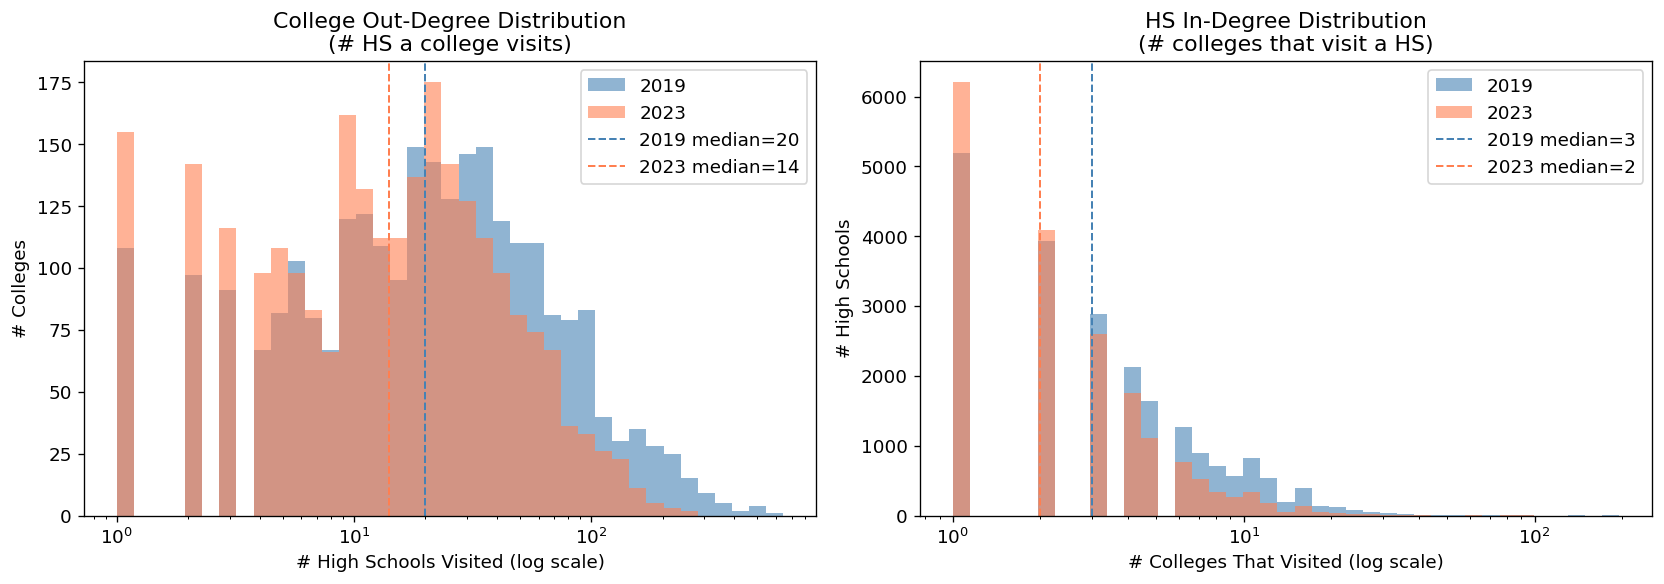

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- College out-degree: HS visited per college ---
ax = axes[0]
bins = np.logspace(0, np.log10(max(max(od19), max(od23)) + 1), 40)
ax.hist(od19, bins=bins, alpha=0.6, label='2019', color='steelblue')
ax.hist(od23, bins=bins, alpha=0.6, label='2023', color='coral')
ax.set_xscale('log')
ax.set_xlabel('# High Schools Visited (log scale)')
ax.set_ylabel('# Colleges')
ax.set_title('College Out-Degree Distribution\n(# HS a college visits)')
ax.axvline(np.median(od19), color='steelblue', linestyle='--', linewidth=1.2, label=f'2019 median={int(np.median(od19))}')
ax.axvline(np.median(od23), color='coral',     linestyle='--', linewidth=1.2, label=f'2023 median={int(np.median(od23))}')
ax.legend()

# --- HS in-degree: colleges visiting per HS ---
ax = axes[1]
bins2 = np.logspace(0, np.log10(max(max(id19), max(id23)) + 1), 40)
ax.hist(id19, bins=bins2, alpha=0.6, label='2019', color='steelblue')
ax.hist(id23, bins=bins2, alpha=0.6, label='2023', color='coral')
ax.set_xscale('log')
ax.set_xlabel('# Colleges That Visited (log scale)')
ax.set_ylabel('# High Schools')
ax.set_title('HS In-Degree Distribution\n(# colleges that visit a HS)')
ax.axvline(np.median(id19), color='steelblue', linestyle='--', linewidth=1.2, label=f'2019 median={int(np.median(id19))}')
ax.axvline(np.median(id23), color='coral',     linestyle='--', linewidth=1.2, label=f'2023 median={int(np.median(id23))}')
ax.legend()

plt.tight_layout()
plt.savefig('../data/network_degree_distributions.png', bbox_inches='tight')
plt.show()

## Top Colleges by Reach (Out-Degree)

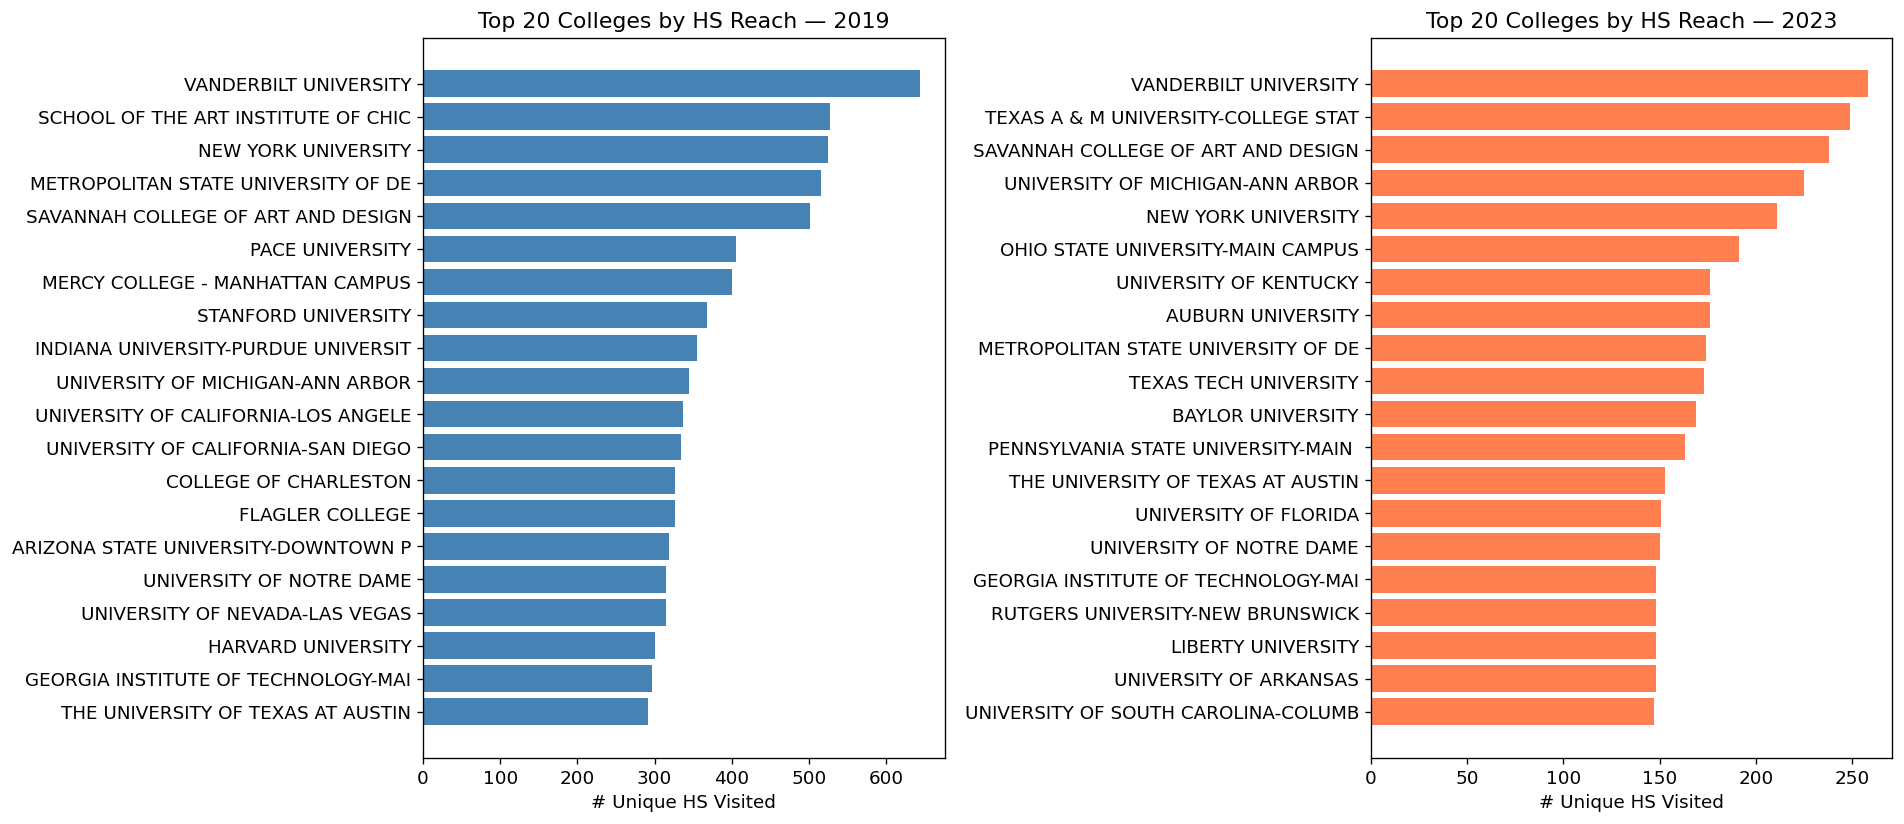


2019 top 10:
                                             name state  control  out_degree
                            VANDERBILT UNIVERSITY    TN      2.0         644
           SCHOOL OF THE ART INSTITUTE OF CHICAGO    IL      2.0         528
                              NEW YORK UNIVERSITY    NY      2.0         525
          METROPOLITAN STATE UNIVERSITY OF DENVER    CO      1.0         516
               SAVANNAH COLLEGE OF ART AND DESIGN    GA      2.0         502
                                  PACE UNIVERSITY    NY      2.0         405
                 MERCY COLLEGE - MANHATTAN CAMPUS    NY      NaN         400
                              STANFORD UNIVERSITY    CA      2.0         368
INDIANA UNIVERSITY-PURDUE UNIVERSITY-INDIANAPOLIS    IN      1.0         355
                 UNIVERSITY OF MICHIGAN-ANN ARBOR    MI      1.0         345

2023 top 10:
                                   name state  control  out_degree
                  VANDERBILT UNIVERSITY    TN      2.0    

In [6]:
def top_colleges(G, year, n=20):
    college_nodes = [(n, d) for n, d in G.nodes(data=True) if d.get('node_type') == 'college']
    rows = [{'college_id': nid, 'name': d.get('name', nid),
             'state': d.get('state'), 'control': d.get('inst_control'),
             'out_degree': G.out_degree(nid)} for nid, d in college_nodes]
    return pd.DataFrame(rows).sort_values('out_degree', ascending=False).head(n)

top19 = top_colleges(G2019, 2019)
top23 = top_colleges(G2023, 2023)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, top, yr, color in [(axes[0], top19, 2019, 'steelblue'), (axes[1], top23, 2023, 'coral')]:
    labels = top['name'].str[:35]
    ax.barh(labels[::-1], top['out_degree'][::-1], color=color)
    ax.set_xlabel('# Unique HS Visited')
    ax.set_title(f'Top 20 Colleges by HS Reach — {yr}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/network_top_colleges.png', bbox_inches='tight')
plt.show()

print('\n2019 top 10:')
print(top19[['name','state','control','out_degree']].head(10).to_string(index=False))
print('\n2023 top 10:')
print(top23[['name','state','control','out_degree']].head(10).to_string(index=False))

## Most-Visited High Schools (In-Degree)

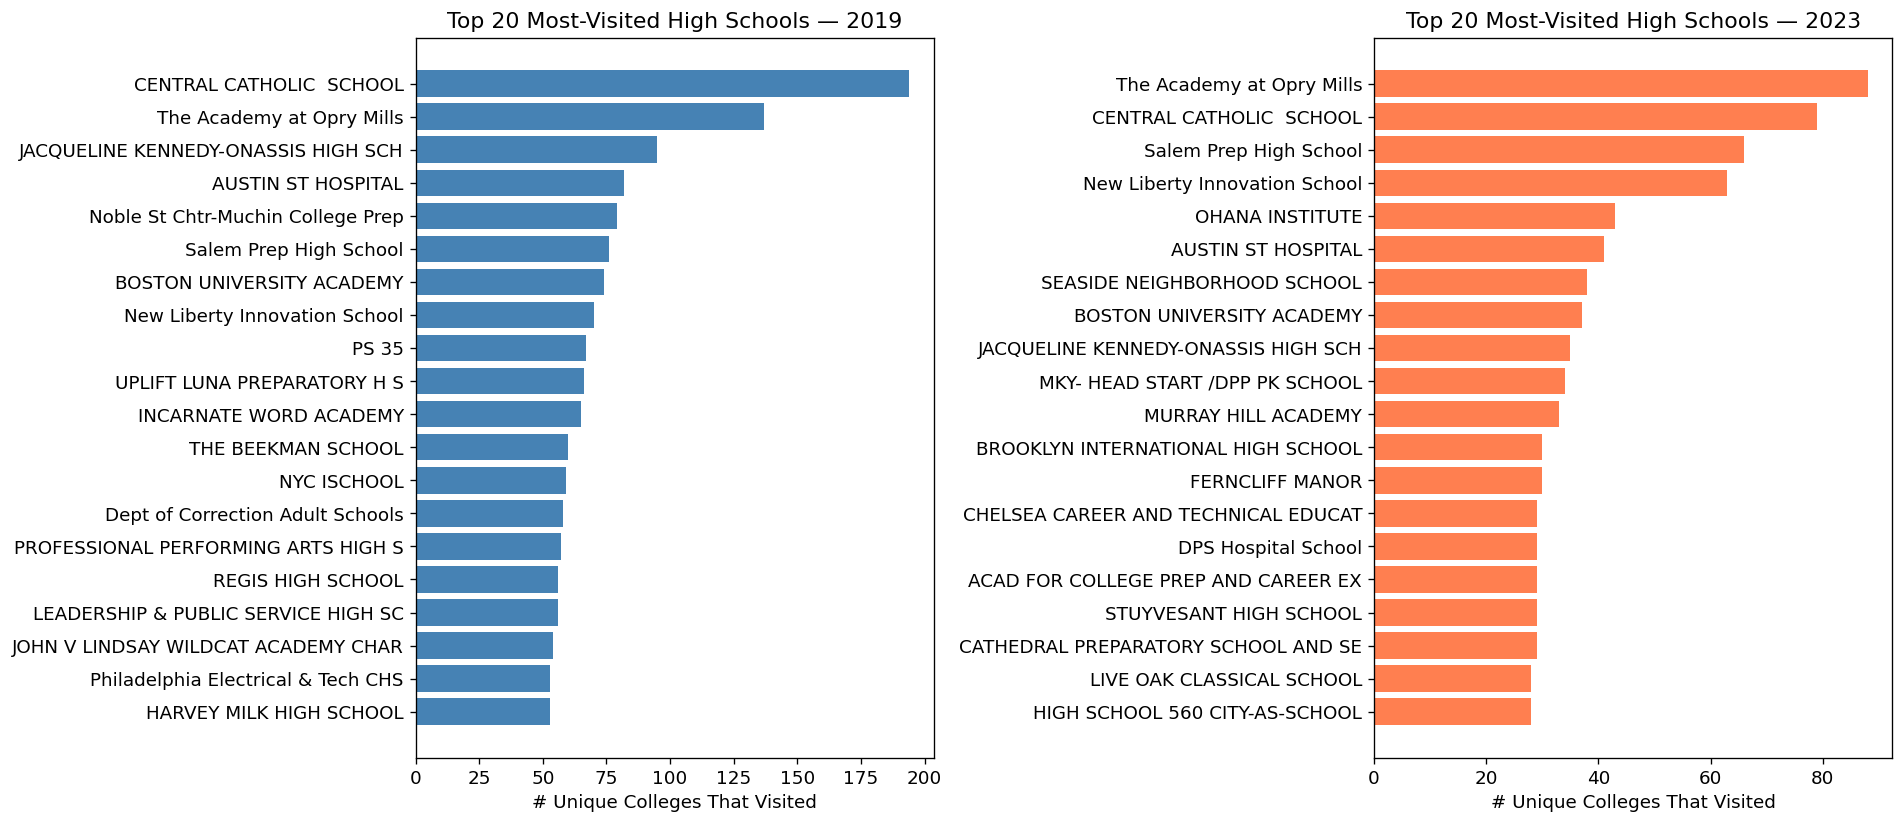


2019 top 10:
                                  name state school_type  enrollment  in_degree
              CENTRAL CATHOLIC  SCHOOL    LA     private       485.0        194
             The Academy at Opry Mills    TN      public        44.0        137
JACQUELINE KENNEDY-ONASSIS HIGH SCHOOL    NY      public       308.0         95
                    AUSTIN ST HOSPITAL    TX      public        21.0         82
     Noble St Chtr-Muchin College Prep    IL      public       972.0         79
                Salem Prep High School    MA      public        19.0         76
             BOSTON UNIVERSITY ACADEMY    MA     private       193.0         74
         New Liberty Innovation School    MA      public        49.0         70
                                 PS 35    NY      public       271.0         67
           UPLIFT LUNA PREPARATORY H S    TX      public       475.0         66

2023 top 10:
                                  name state school_type  enrollment  in_degree
            

In [7]:
def top_hs(G, year, n=20):
    hs_nodes = [(nid, d) for nid, d in G.nodes(data=True) if d.get('node_type') == 'hs']
    rows = [{'hs_id': nid, 'name': d.get('name', nid),
             'state': d.get('state'), 'enrollment': d.get('enrollment'),
             'pct_frl': d.get('pct_frl'), 'locale': d.get('locale'),
             'school_type': d.get('school_type'),
             'in_degree': G.in_degree(nid)} for nid, d in hs_nodes]
    return pd.DataFrame(rows).sort_values('in_degree', ascending=False).head(n)

ths19 = top_hs(G2019, 2019)
ths23 = top_hs(G2023, 2023)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, top, yr, color in [(axes[0], ths19, 2019, 'steelblue'), (axes[1], ths23, 2023, 'coral')]:
    labels = top['name'].str[:35]
    ax.barh(labels[::-1], top['in_degree'][::-1], color=color)
    ax.set_xlabel('# Unique Colleges That Visited')
    ax.set_title(f'Top 20 Most-Visited High Schools — {yr}')

plt.tight_layout()
plt.savefig('../data/network_top_hs.png', bbox_inches='tight')
plt.show()

print('\n2019 top 10:')
print(ths19[['name','state','school_type','enrollment','in_degree']].head(10).to_string(index=False))
print('\n2023 top 10:')
print(ths23[['name','state','school_type','enrollment','in_degree']].head(10).to_string(index=False))

## Change in Reach: 2019 → 2023

For colleges present in both years, how did their HS recruiting footprint change?

In [8]:
col19 = {n: G2019.out_degree(n) for n, d in G2019.nodes(data=True) if d.get('node_type') == 'college'}
col23 = {n: G2023.out_degree(n) for n, d in G2023.nodes(data=True) if d.get('node_type') == 'college'}

both = set(col19) & set(col23)
change = pd.DataFrame({
    'college_id': list(both),
    'reach_2019': [col19[c] for c in both],
    'reach_2023': [col23[c] for c in both],
})
change['delta'] = change['reach_2023'] - change['reach_2019']
change['pct_change'] = change['delta'] / change['reach_2019']
change['name'] = change['college_id'].map(
    {n: d.get('name') for n, d in G2019.nodes(data=True)})
change['control'] = change['college_id'].map(
    {n: d.get('inst_control') for n, d in G2019.nodes(data=True)})

print(f'Colleges in both years: {len(change)}')
print(f'Expanded reach  (2023 > 2019): {(change["delta"] > 0).sum()}')
print(f'Contracted reach(2023 < 2019): {(change["delta"] < 0).sum()}')
print(f'Unchanged:                     {(change["delta"] == 0).sum()}')
print(f'\nMedian delta: {change["delta"].median():.0f} HS')
print(f'Mean delta:   {change["delta"].mean():.1f} HS')

Colleges in both years: 2499
Expanded reach  (2023 > 2019): 525
Contracted reach(2023 < 2019): 1850
Unchanged:                     124

Median delta: -6 HS
Mean delta:   -16.0 HS


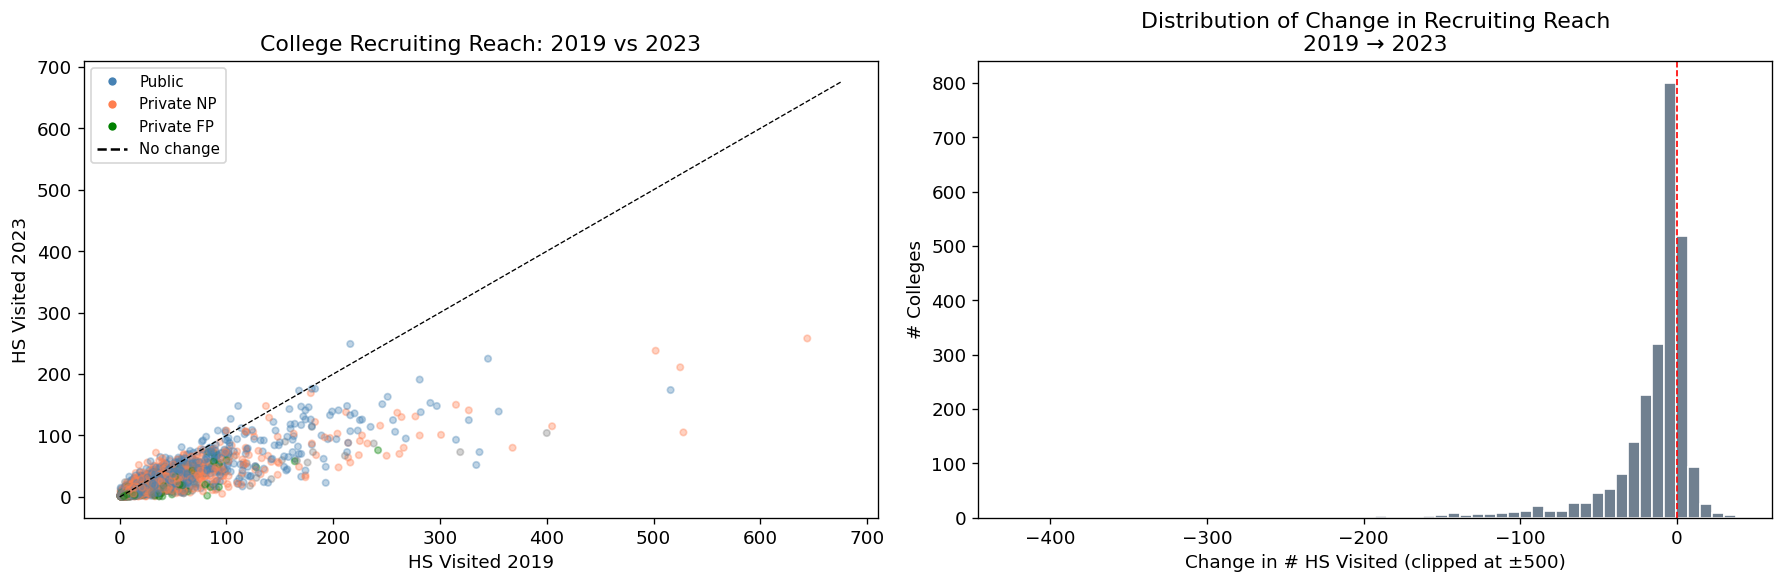


Biggest expansions:
                                  name  control  reach_2019  reach_2023  delta
          ABILENE CHRISTIAN UNIVERSITY      2.0          34          72     38
                UNIVERSITY OF ARKANSAS      1.0         111         148     37
      UNIVERSITY OF MARY HARDIN-BAYLOR      2.0          18          52     34
TEXAS A & M UNIVERSITY-COLLEGE STATION      1.0         216         249     33
                 CEDARVILLE UNIVERSITY      2.0          26          56     30
         PRAIRIE VIEW A & M UNIVERSITY      1.0          29          58     29
    UNIVERSITY OF WISCONSIN-EAU CLAIRE      1.0          38          65     27
                     ASBURY UNIVERSITY      2.0          15          39     24
               ALBANY STATE UNIVERSITY      1.0           9          33     24
                          IONA COLLEGE      2.0          40          63     23

Biggest contractions:
                                   name  control  reach_2019  reach_2023  delta
 SCHOOL

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: 2019 reach vs 2023 reach
ax = axes[0]
colors = change['control'].map({1.0: 'steelblue', 2.0: 'coral', 3.0: 'green'}).fillna('gray')
ax.scatter(change['reach_2019'], change['reach_2023'], alpha=0.35, s=15, c=colors)
lim = max(change['reach_2019'].max(), change['reach_2023'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='No change')
ax.set_xlabel('HS Visited 2019')
ax.set_ylabel('HS Visited 2023')
ax.set_title('College Recruiting Reach: 2019 vs 2023')
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Public'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',     label='Private NP'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='green',     label='Private FP'),
              Line2D([0],[0], color='k', linestyle='--', label='No change')]
ax.legend(handles=legend_els, fontsize=9)

# Distribution of deltas
ax = axes[1]
ax.hist(change['delta'].clip(-500, 500), bins=60, color='slategray', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Change in # HS Visited (clipped at ±500)')
ax.set_ylabel('# Colleges')
ax.set_title('Distribution of Change in Recruiting Reach\n2019 → 2023')

plt.tight_layout()
plt.savefig('../data/network_reach_change.png', bbox_inches='tight')
plt.show()

print('\nBiggest expansions:')
print(change.nlargest(10, 'delta')[['name','control','reach_2019','reach_2023','delta']].to_string(index=False))
print('\nBiggest contractions:')
print(change.nsmallest(10, 'delta')[['name','control','reach_2019','reach_2023','delta']].to_string(index=False))

## HS Attention: Never Visited vs Highly Visited

In [10]:
# How many HS in the filtered dataset were never visited in 2019 or 2023?
hs_in_2019 = {n for n, d in G2019.nodes(data=True) if d.get('node_type') == 'hs'}
hs_in_2023 = {n for n, d in G2023.nodes(data=True) if d.get('node_type') == 'hs'}

print(f'HS visited in 2019:        {len(hs_in_2019):,}')
print(f'HS visited in 2023:        {len(hs_in_2023):,}')
print(f'HS visited in BOTH years:  {len(hs_in_2019 & hs_in_2023):,}')
print(f'HS visited in 2019 only:   {len(hs_in_2019 - hs_in_2023):,}')
print(f'HS visited in 2023 only:   {len(hs_in_2023 - hs_in_2019):,}')
print()

# In-degree percentiles for HS
for yr, G in [('2019', G2019), ('2023', G2023)]:
    hs_in = [G.in_degree(n) for n, d in G.nodes(data=True) if d.get('node_type') == 'hs']
    print(f'{yr} HS in-degree percentiles:')
    for p in [25, 50, 75, 90, 95, 99]:
        print(f'  p{p}: {np.percentile(hs_in, p):.0f}')
    print(f'  Top 1% threshold: {np.percentile(hs_in, 99):.0f} colleges visiting')
    print()

HS visited in 2019:        21,692
HS visited in 2023:        18,495
HS visited in BOTH years:  15,988
HS visited in 2019 only:   5,704
HS visited in 2023 only:   2,507

2019 HS in-degree percentiles:
  p25: 2
  p50: 3
  p75: 6
  p90: 10
  p95: 13
  p99: 23
  Top 1% threshold: 23 colleges visiting

2023 HS in-degree percentiles:
  p25: 1
  p50: 2
  p75: 4
  p90: 7
  p95: 9
  p99: 17
  Top 1% threshold: 17 colleges visiting



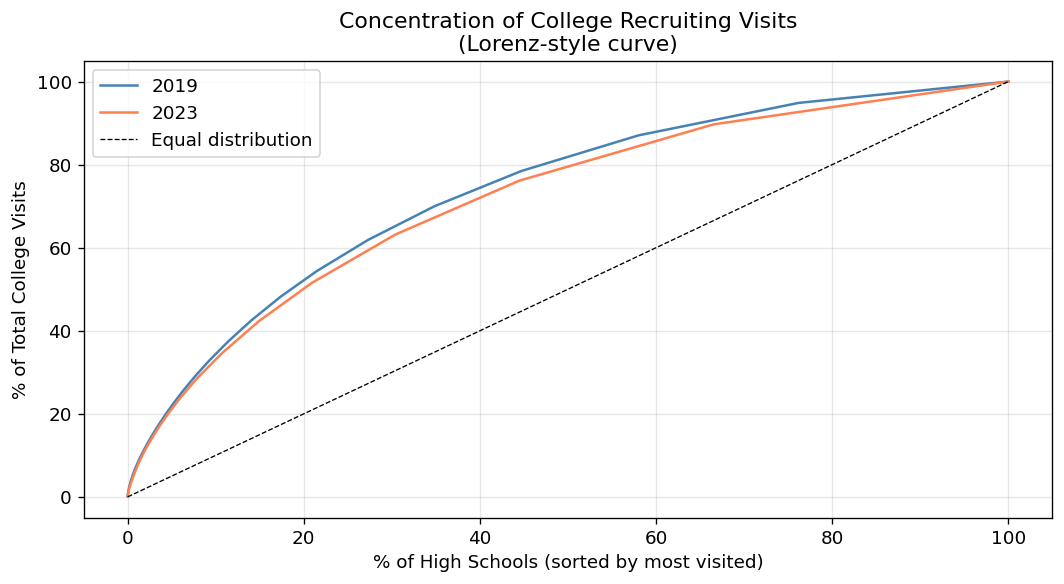

2019: top 10% of HS receive 34.4% of all college visits
2023: top 10% of HS receive 33.1% of all college visits


In [11]:
# Cumulative distribution of HS in-degree — what share of HS gets most of the attention?
fig, ax = plt.subplots(figsize=(9, 5))

for yr, G, color in [('2019', G2019, 'steelblue'), ('2023', G2023, 'coral')]:
    hs_in = sorted([G.in_degree(n) for n, d in G.nodes(data=True) if d.get('node_type') == 'hs'], reverse=True)
    total_visits = sum(hs_in)
    cum_share = np.cumsum(hs_in) / total_visits
    hs_pct = np.arange(1, len(hs_in)+1) / len(hs_in)
    ax.plot(hs_pct * 100, cum_share * 100, label=yr, color=color)

ax.plot([0,100],[0,100],'k--', linewidth=0.8, label='Equal distribution')
ax.set_xlabel('% of High Schools (sorted by most visited)')
ax.set_ylabel('% of Total College Visits')
ax.set_title('Concentration of College Recruiting Visits\n(Lorenz-style curve)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/network_visit_concentration.png', bbox_inches='tight')
plt.show()

# What % of visits go to top 10% of HS?
for yr, G in [('2019', G2019), ('2023', G2023)]:
    hs_in = sorted([G.in_degree(n) for n, d in G.nodes(data=True) if d.get('node_type') == 'hs'], reverse=True)
    top10_cutoff = max(1, int(len(hs_in) * 0.10))
    top10_share = sum(hs_in[:top10_cutoff]) / sum(hs_in)
    print(f'{yr}: top 10% of HS receive {top10_share:.1%} of all college visits')

## HS In-Degree vs Enrollment

Do bigger schools get more visits, or is something else going on?

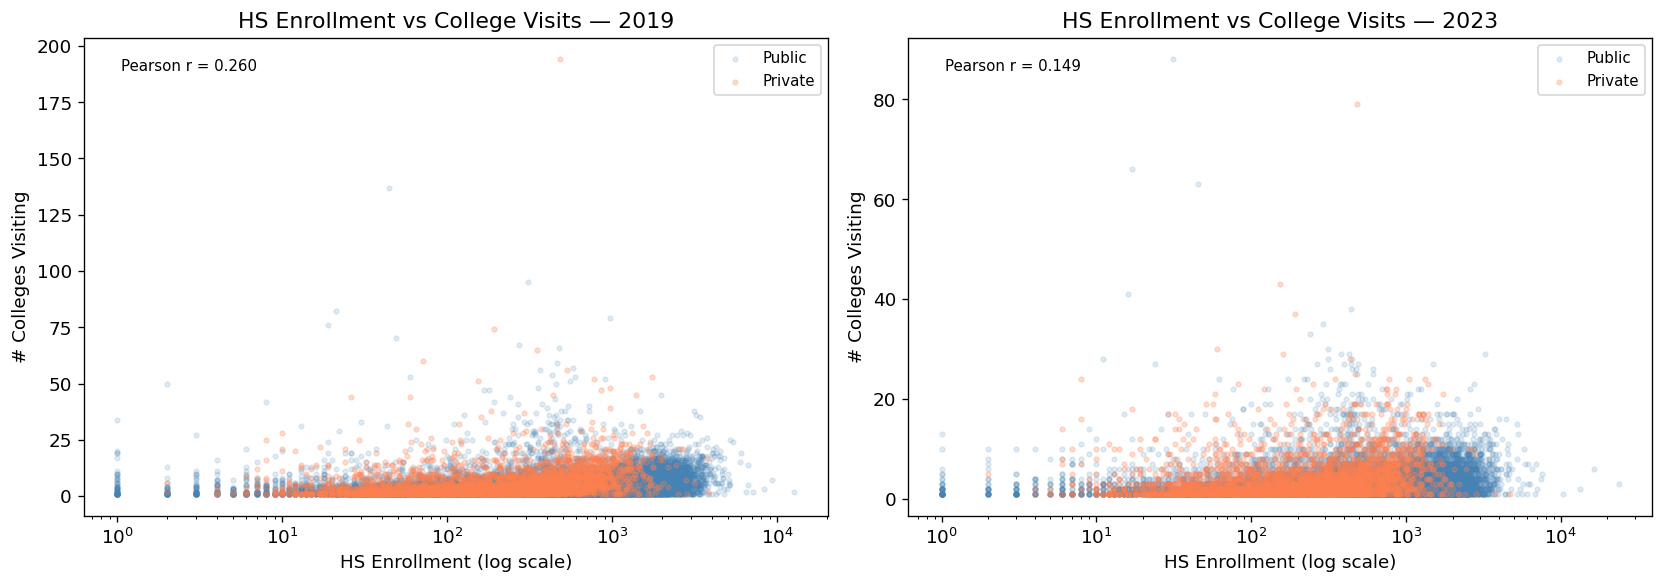

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, yr, G, color in [(axes[0], '2019', G2019, 'steelblue'), (axes[1], '2023', G2023, 'coral')]:
    rows = [{'enrollment': d.get('enrollment'), 'in_degree': G.in_degree(n),
             'school_type': d.get('school_type')}
            for n, d in G.nodes(data=True) if d.get('node_type') == 'hs']
    sub = pd.DataFrame(rows).dropna(subset=['enrollment'])
    sub = sub[sub['enrollment'] > 0]

    pub = sub[sub['school_type'] == 'public']
    prv = sub[sub['school_type'] == 'private']
    ax.scatter(pub['enrollment'], pub['in_degree'], alpha=0.15, s=8, color='steelblue', label='Public')
    ax.scatter(prv['enrollment'], prv['in_degree'], alpha=0.25, s=8, color='coral', label='Private')
    ax.set_xscale('log')
    ax.set_xlabel('HS Enrollment (log scale)')
    ax.set_ylabel('# Colleges Visiting')
    ax.set_title(f'HS Enrollment vs College Visits — {yr}')
    ax.legend(fontsize=9)

    corr = sub[['enrollment','in_degree']].corr().iloc[0,1]
    ax.text(0.05, 0.93, f'Pearson r = {corr:.3f}', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.savefig('../data/network_enrollment_vs_visits.png', bbox_inches='tight')
plt.show()

## Network Visualization (Top 50 Colleges × Their Most-Visited HS)

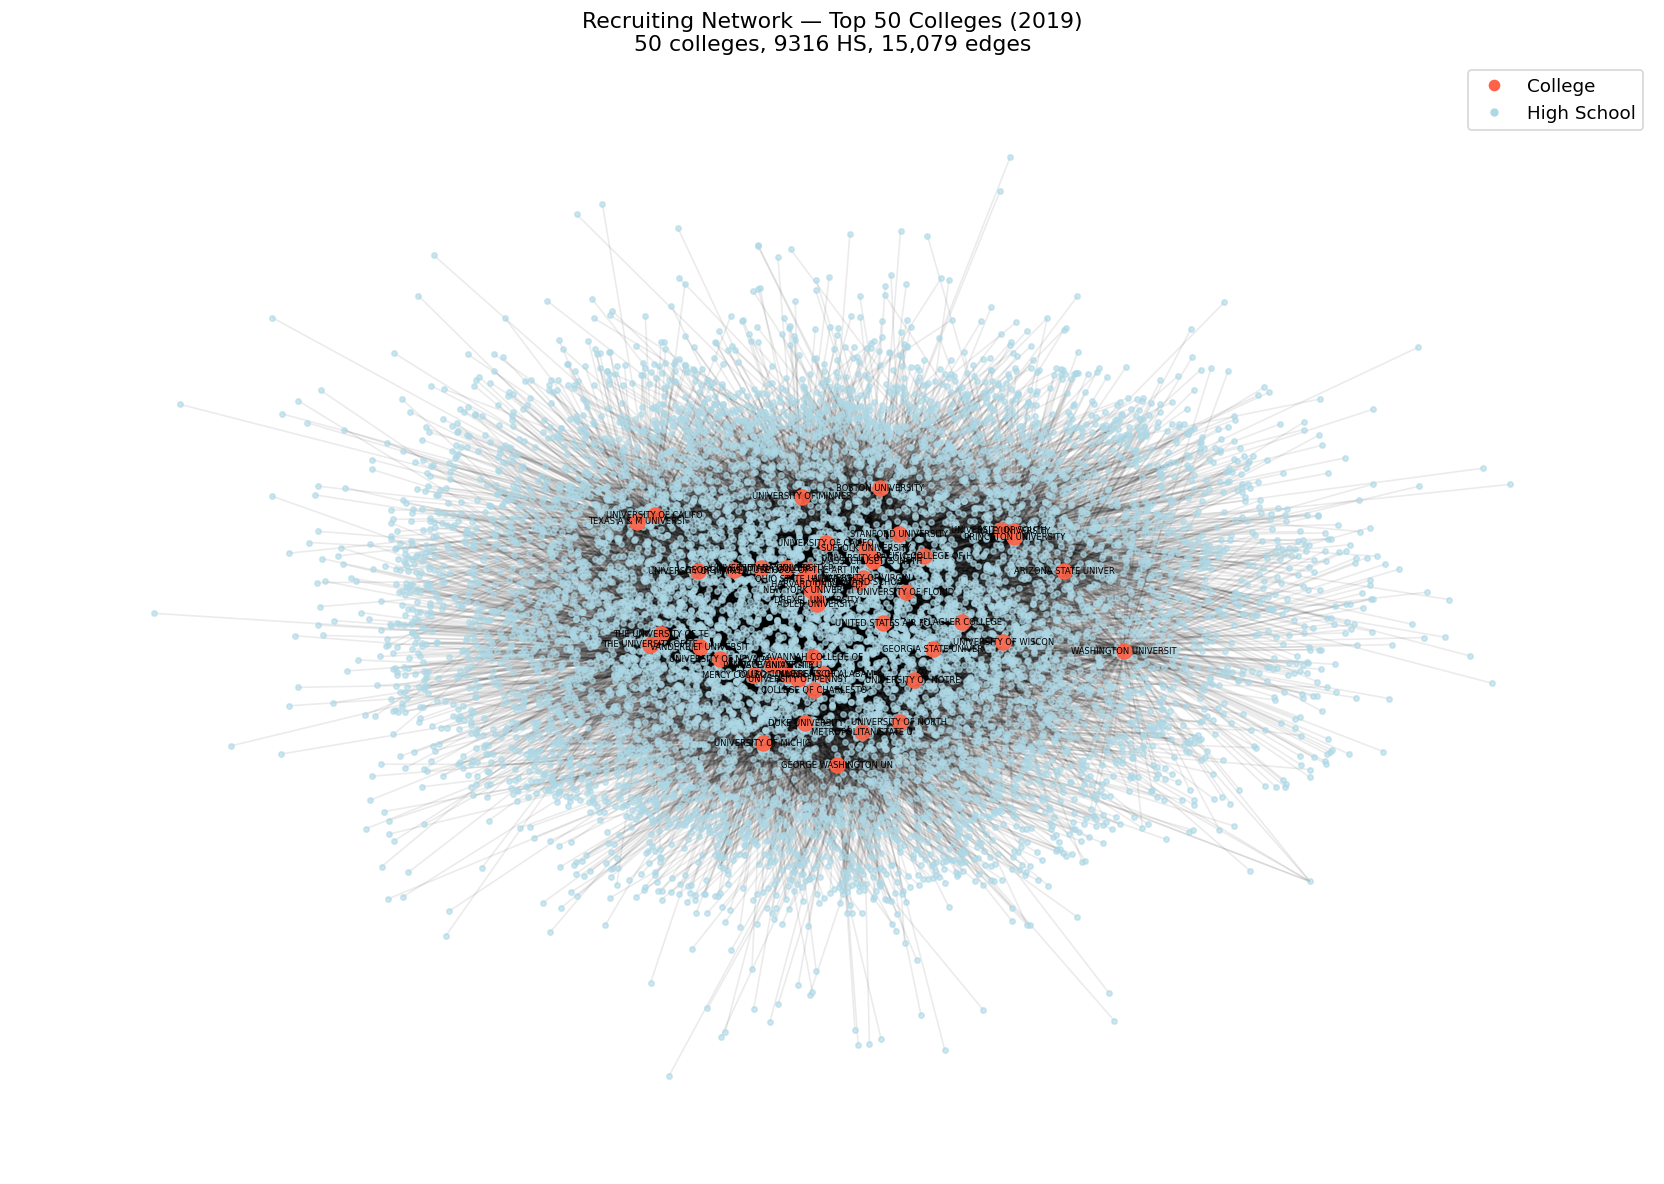

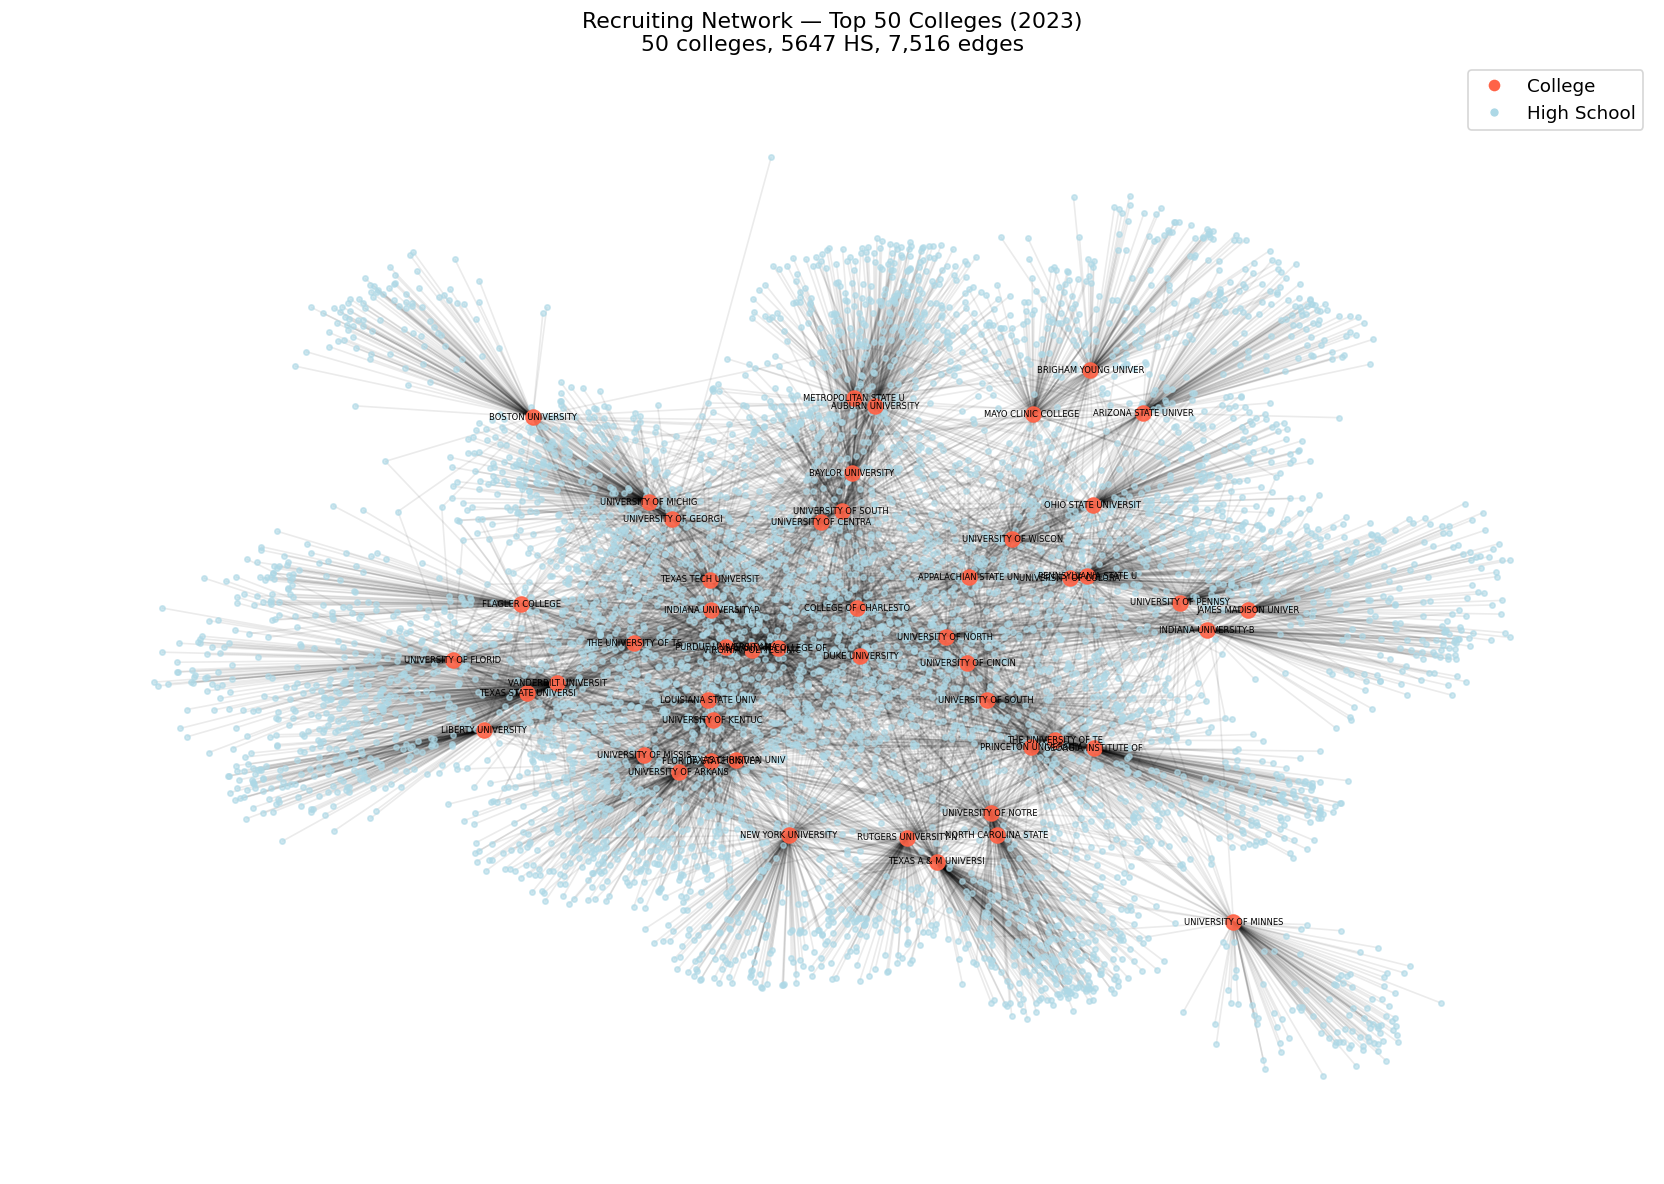

In [15]:
def draw_subgraph(G, year, top_n_colleges=50):
    """Draw a spring-layout subgraph of top colleges and their HS connections."""
    college_nodes = sorted(
        [(n, G.out_degree(n)) for n, d in G.nodes(data=True) if d.get('node_type') == 'college'],
        key=lambda x: -x[1])[:top_n_colleges]
    top_col_ids = {n for n, _ in college_nodes}

    sub = G.subgraph(
        top_col_ids | {v for u, v in G.edges() if u in top_col_ids}
    )

    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(sub, seed=42, k=0.3)

    col_ids = [n for n, d in sub.nodes(data=True) if d.get('node_type') == 'college']
    hs_ids  = [n for n, d in sub.nodes(data=True) if d.get('node_type') == 'hs']

    nx.draw_networkx_nodes(sub, pos, nodelist=hs_ids,  node_size=10, node_color='lightblue', alpha=0.6, ax=ax)
    nx.draw_networkx_nodes(sub, pos, nodelist=col_ids, node_size=80, node_color='tomato',    alpha=0.9, ax=ax)
    nx.draw_networkx_edges(sub, pos, alpha=0.08, arrows=False, ax=ax)
    nx.draw_networkx_labels(sub, pos,
        labels={n: sub.nodes[n].get('name','')[:20] for n in col_ids},
        font_size=5, ax=ax)

    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=8, label='College'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='lightblue', markersize=6, label='High School')
    ])
    ax.set_title(f'Recruiting Network — Top {top_n_colleges} Colleges ({year})\n'
                 f'{len(col_ids)} colleges, {len(hs_ids)} HS, {sub.number_of_edges():,} edges')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'../data/network_graph_{year}.png', bbox_inches='tight', dpi=150)
    plt.show()

draw_subgraph(G2019, 2019)
draw_subgraph(G2023, 2023)

## Race Composition & College Recruiting Visits

Do high schools with different racial compositions receive different levels of recruiting attention? We look at correlations, majority-race categories, and quartile breakdowns for 2019 and 2023.

In [16]:
# Build a HS-level dataframe with in-degree + race columns for each year
race_cols = ['hs_id', 'hs_pct_white', 'hs_pct_black', 'hs_pct_hispanic',
             'hs_pct_asian', 'hs_pct_aian', 'hs_pct_nhpi', 'hs_pct_two_or_more',
             'hs_enrollment', 'school_type']

race_dfs = {}
for yr, G in [(2019, G2019), (2023, G2023)]:
    # in-degree for every HS node
    in_deg = {n: G.in_degree(n) for n, d in G.nodes(data=True) if d.get('node_type') == 'hs'}
    deg_df = pd.DataFrame({'hs_id': list(in_deg.keys()), 'in_degree': list(in_deg.values())})

    # race data from the filtered df (one row per HS, take first occurrence)
    race_data = (df[df['cycle'] == yr]
                 .drop_duplicates('hs_id')[race_cols]
                 .astype({'hs_id': str}))

    merged = deg_df.merge(race_data.astype({'hs_id': str}), on='hs_id', how='left')

    # pct_urm = black + hispanic + aian + nhpi + two_or_more
    merged['pct_urm'] = (merged['hs_pct_black'].fillna(0) +
                         merged['hs_pct_hispanic'].fillna(0) +
                         merged['hs_pct_aian'].fillna(0) +
                         merged['hs_pct_nhpi'].fillna(0) +
                         merged['hs_pct_two_or_more'].fillna(0))

    race_dfs[yr] = merged
    print(f'{yr}: {len(merged):,} HS  |  race data available: {merged["hs_pct_white"].notna().sum():,}')

2019: 21,692 HS  |  race data available: 20,660
2023: 18,495 HS  |  race data available: 17,576


In [17]:
# Correlation table: race % vs in-degree for 2019 and 2023
race_vars = ['hs_pct_white', 'hs_pct_black', 'hs_pct_hispanic',
             'hs_pct_asian', 'hs_pct_aian', 'pct_urm']

corr_rows = []
for yr in [2019, 2023]:
    rdf = race_dfs[yr].dropna(subset=['hs_pct_white'])
    for var in race_vars:
        r = rdf[[var, 'in_degree']].corr().iloc[0, 1]
        corr_rows.append({'year': yr, 'variable': var, 'pearson_r': round(r, 4)})

corr_table = pd.DataFrame(corr_rows).pivot(index='variable', columns='year', values='pearson_r')
corr_table.columns.name = None
corr_table.index.name = None
print('Pearson r: race % vs HS in-degree (# colleges visiting)')
print(corr_table.to_string())

Pearson r: race % vs HS in-degree (# colleges visiting)
                   2019    2023
hs_pct_aian     -0.0641 -0.0509
hs_pct_asian     0.1625  0.1152
hs_pct_black     0.0426  0.0524
hs_pct_hispanic  0.0262  0.0357
hs_pct_white    -0.0773 -0.0811
pct_urm          0.0393  0.0500


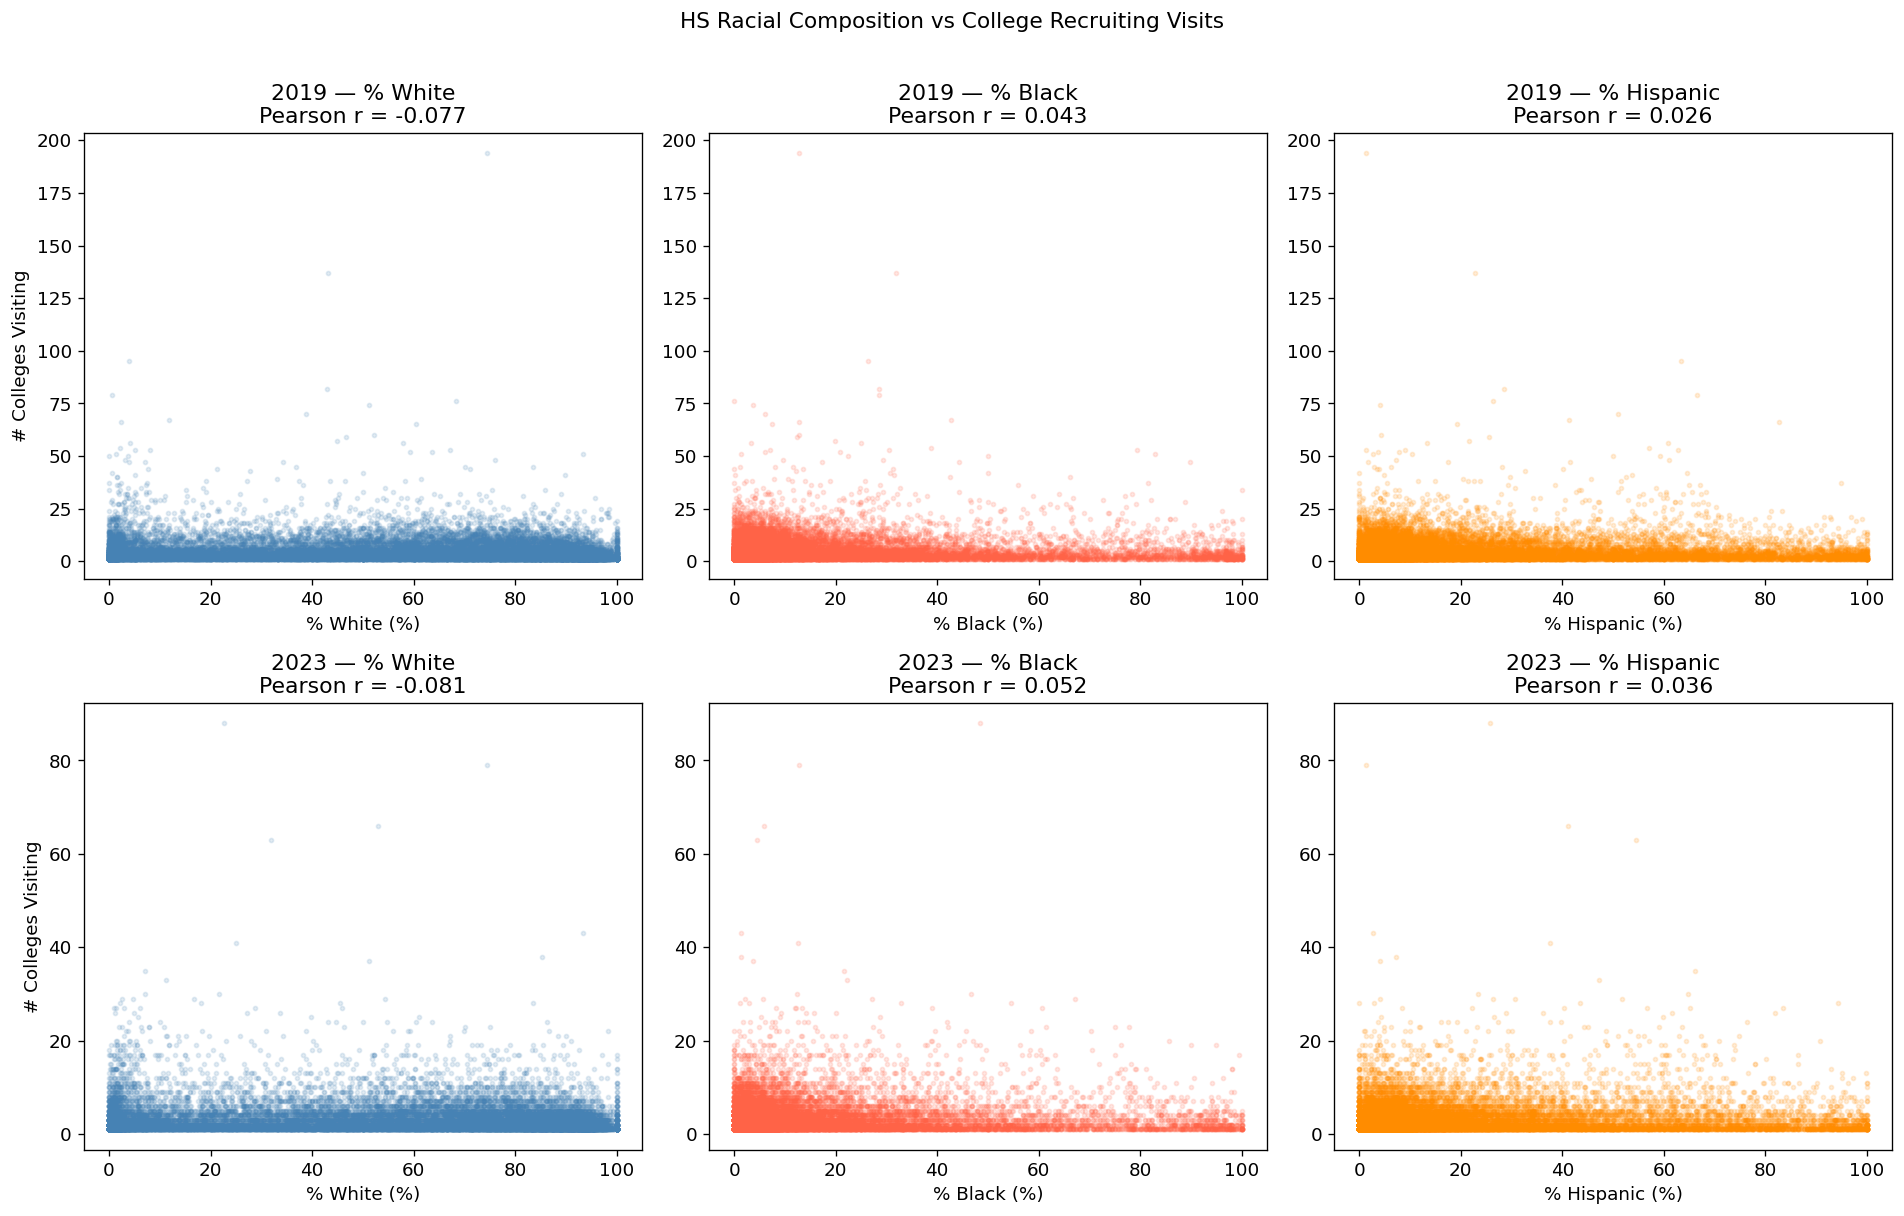

In [18]:
# Scatter: pct_white, pct_black, pct_hispanic vs in-degree (2019 and 2023)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_vars = [
    ('hs_pct_white',    '% White',    'steelblue'),
    ('hs_pct_black',    '% Black',    'tomato'),
    ('hs_pct_hispanic', '% Hispanic', 'darkorange'),
]

for row_i, (yr, rdf) in enumerate([(2019, race_dfs[2019]), (2023, race_dfs[2023])]):
    sub = rdf.dropna(subset=['hs_pct_white'])
    for col_i, (var, label, color) in enumerate(plot_vars):
        ax = axes[row_i][col_i]
        ax.scatter(sub[var] * 100, sub['in_degree'], alpha=0.15, s=6, color=color)
        r = sub[[var, 'in_degree']].corr().iloc[0, 1]
        ax.set_xlabel(f'{label} (%)')
        ax.set_ylabel('# Colleges Visiting' if col_i == 0 else '')
        ax.set_title(f'{yr} — {label}\nPearson r = {r:.3f}')

plt.suptitle('HS Racial Composition vs College Recruiting Visits', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/network_race_scatter.png', bbox_inches='tight')
plt.show()

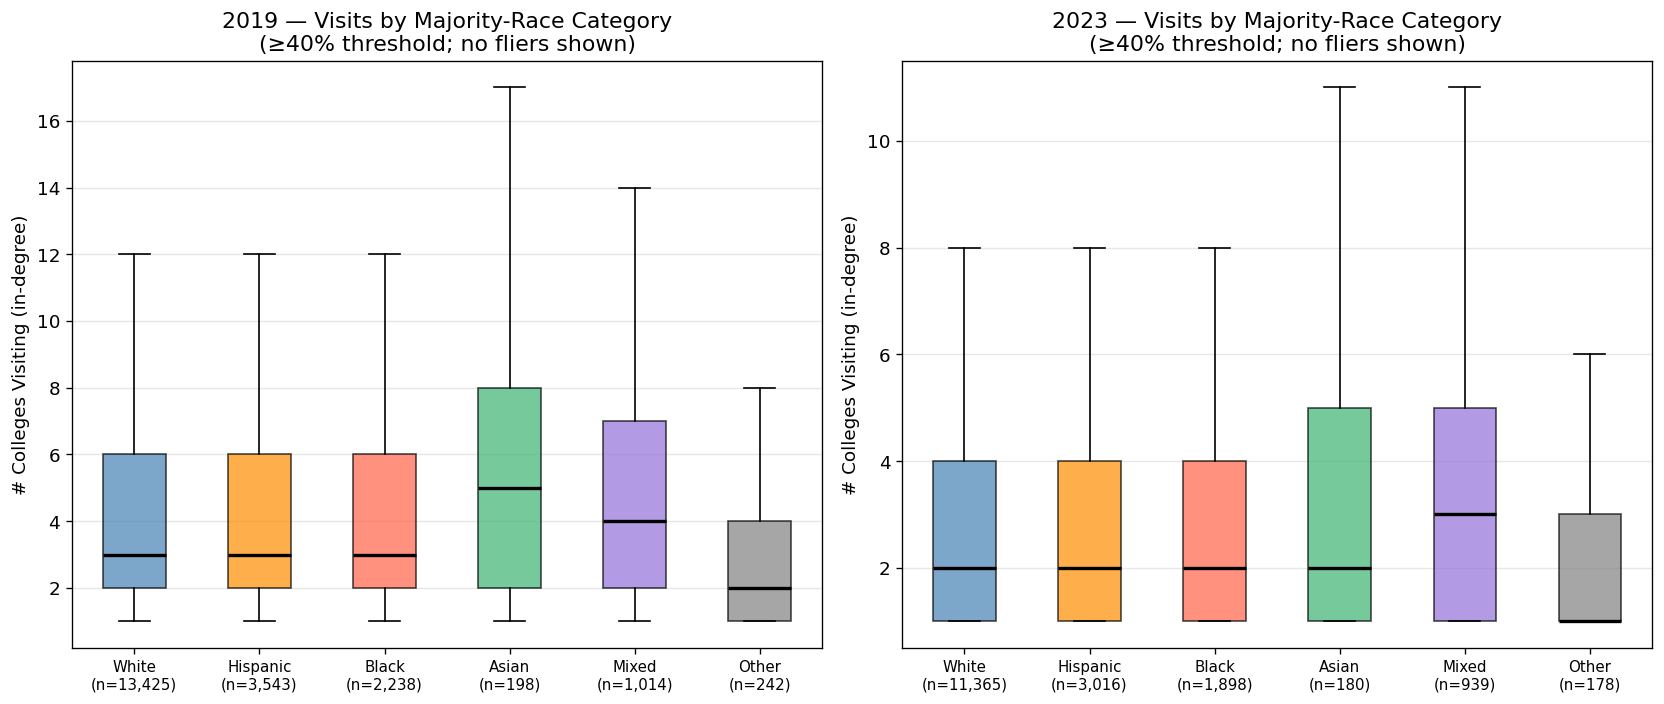

Median # colleges visiting by majority-race group:

2019:
               median  mean      n
majority_race                     
White             3.0  4.59  13425
Hispanic          3.0  4.94   3543
Black             3.0  4.72   2238
Asian             5.0  6.23    198
Mixed             4.0  5.40   1014
Other             2.0  3.29    242

2023:
               median  mean      n
majority_race                     
White             2.0  3.16  11365
Hispanic          2.0  3.48   3016
Black             2.0  3.44   1898
Asian             2.0  3.80    180
Mixed             3.0  3.84    939
Other             1.0  2.32    178


In [19]:
# Majority-race categorization: assign each HS to its plurality racial group
# (only for public schools, which have reliable race data)

def assign_majority_race(row):
    groups = {
        'White':    row.get('hs_pct_white', 0) or 0,
        'Black':    row.get('hs_pct_black', 0) or 0,
        'Hispanic': row.get('hs_pct_hispanic', 0) or 0,
        'Asian':    row.get('hs_pct_asian', 0) or 0,
        'Other':    (row.get('hs_pct_aian', 0) or 0) +
                    (row.get('hs_pct_nhpi', 0) or 0) +
                    (row.get('hs_pct_two_or_more', 0) or 0),
    }
    max_grp = max(groups, key=groups.get)
    return max_grp if groups[max_grp] >= 0.40 else 'Mixed'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = ['White', 'Hispanic', 'Black', 'Asian', 'Mixed', 'Other']
palette = {'White': 'steelblue', 'Black': 'tomato', 'Hispanic': 'darkorange',
           'Asian': 'mediumseagreen', 'Mixed': 'mediumpurple', 'Other': 'gray'}

for ax, yr in zip(axes, [2019, 2023]):
    rdf = race_dfs[yr].dropna(subset=['hs_pct_white']).copy()
    rdf['majority_race'] = rdf.apply(assign_majority_race, axis=1)

    counts = rdf['majority_race'].value_counts()
    medians = rdf.groupby('majority_race')['in_degree'].median().reindex(order).dropna()

    groups_present = [g for g in order if g in rdf['majority_race'].values]
    data_by_group = [rdf[rdf['majority_race'] == g]['in_degree'].values for g in groups_present]
    colors = [palette[g] for g in groups_present]
    labels = [f"{g}\n(n={counts.get(g,0):,})" for g in groups_present]

    bp = ax.boxplot(data_by_group, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(groups_present) + 1))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('# Colleges Visiting (in-degree)')
    ax.set_title(f'{yr} — Visits by Majority-Race Category\n(≥40% threshold; no fliers shown)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/network_race_boxplot.png', bbox_inches='tight')
plt.show()

# Print median visits by group for both years
print('Median # colleges visiting by majority-race group:')
for yr in [2019, 2023]:
    rdf = race_dfs[yr].dropna(subset=['hs_pct_white']).copy()
    rdf['majority_race'] = rdf.apply(assign_majority_race, axis=1)
    medians = rdf.groupby('majority_race')['in_degree'].agg(['median','mean','count'])
    medians.columns = ['median', 'mean', 'n']
    medians['mean'] = medians['mean'].round(2)
    print(f'\n{yr}:')
    print(medians.reindex(order).dropna().to_string())

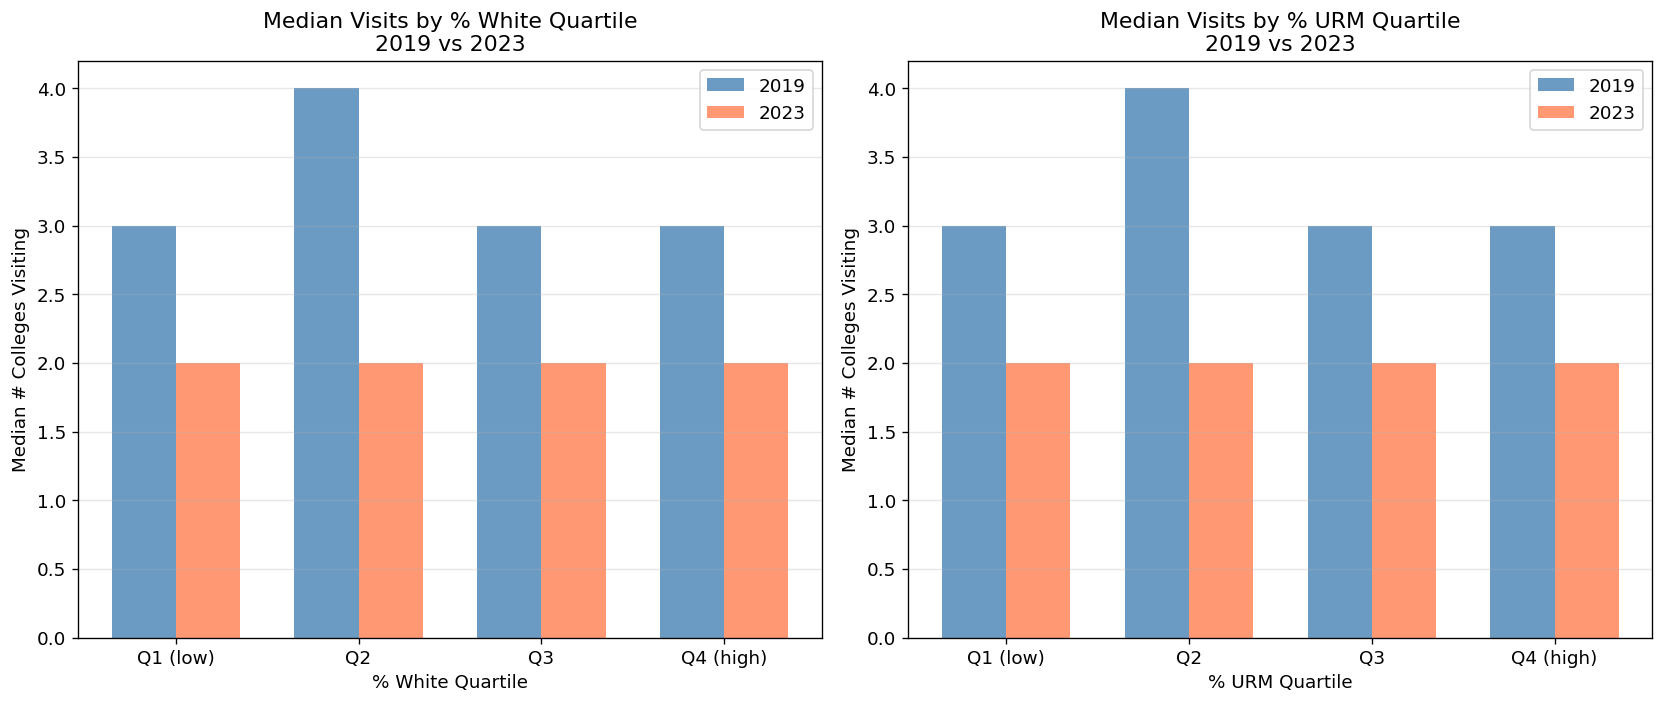


=== Median visits by % White quartile ===
           2019_median  2019_mean  2019_n  2023_median  2023_mean  2023_n
quartile                                                                 
Q1 (low)           3.0       4.99    5165          2.0       3.57    4394
Q2                 4.0       5.16    5165          2.0       3.42    4394
Q3                 3.0       4.98    5165          2.0       3.41    4395
Q4 (high)          3.0       3.67    5165          2.0       2.71    4393

=== Median visits by % URM quartile ===
           2019_median  2019_mean  2019_n  2023_median  2023_mean  2023_n
quartile                                                                 
Q1 (low)           3.0       3.90    5165          2.0       2.88    4395
Q2                 4.0       5.18    5165          2.0       3.47    4393
Q3                 3.0       4.86    5165          2.0       3.23    4394
Q4 (high)          3.0       4.87    5165          2.0       3.54    4394


In [20]:
# Quartile breakdown: split HS into quartiles by % white and % URM,
# compare median visits in 2019 vs 2023

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, split_var, xlabel in [
    (axes[0], 'hs_pct_white', '% White Quartile'),
    (axes[1], 'pct_urm',      '% URM Quartile'),
]:
    results = []
    for yr in [2019, 2023]:
        rdf = race_dfs[yr].dropna(subset=['hs_pct_white']).copy()
        rdf['quartile'] = pd.qcut(rdf[split_var], q=4,
                                   labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
        stats = rdf.groupby('quartile', observed=True)['in_degree'].agg(
            median='median', mean='mean', n='count'
        ).reset_index()
        stats['year'] = yr
        results.append(stats)

    result_df = pd.concat(results)
    quartiles = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
    x = np.arange(len(quartiles))
    width = 0.35

    for i, (yr, color) in enumerate([(2019, 'steelblue'), (2023, 'coral')]):
        vals = result_df[result_df['year'] == yr].set_index('quartile')['median'].reindex(quartiles)
        ax.bar(x + i * width, vals, width, label=str(yr), color=color, alpha=0.8)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(quartiles)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Median # Colleges Visiting')
    ax.set_title(f'Median Visits by {xlabel}\n2019 vs 2023')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/network_race_quartiles.png', bbox_inches='tight')
plt.show()

# Tabular summary
for split_var, label in [('hs_pct_white', '% White'), ('pct_urm', '% URM')]:
    print(f'\n=== Median visits by {label} quartile ===')
    rows = []
    for yr in [2019, 2023]:
        rdf = race_dfs[yr].dropna(subset=['hs_pct_white']).copy()
        rdf['quartile'] = pd.qcut(rdf[split_var], q=4,
                                   labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
        stats = rdf.groupby('quartile', observed=True)['in_degree'].agg(
            median='median', mean='mean', n='count'
        )
        stats.columns = [f'{yr}_median', f'{yr}_mean', f'{yr}_n']
        rows.append(stats)
    print(pd.concat(rows, axis=1).round(2).to_string())

HS in both years with race data: 15,366
Gained visits: 3,213  Lost: 9,281  Unchanged: 2,872


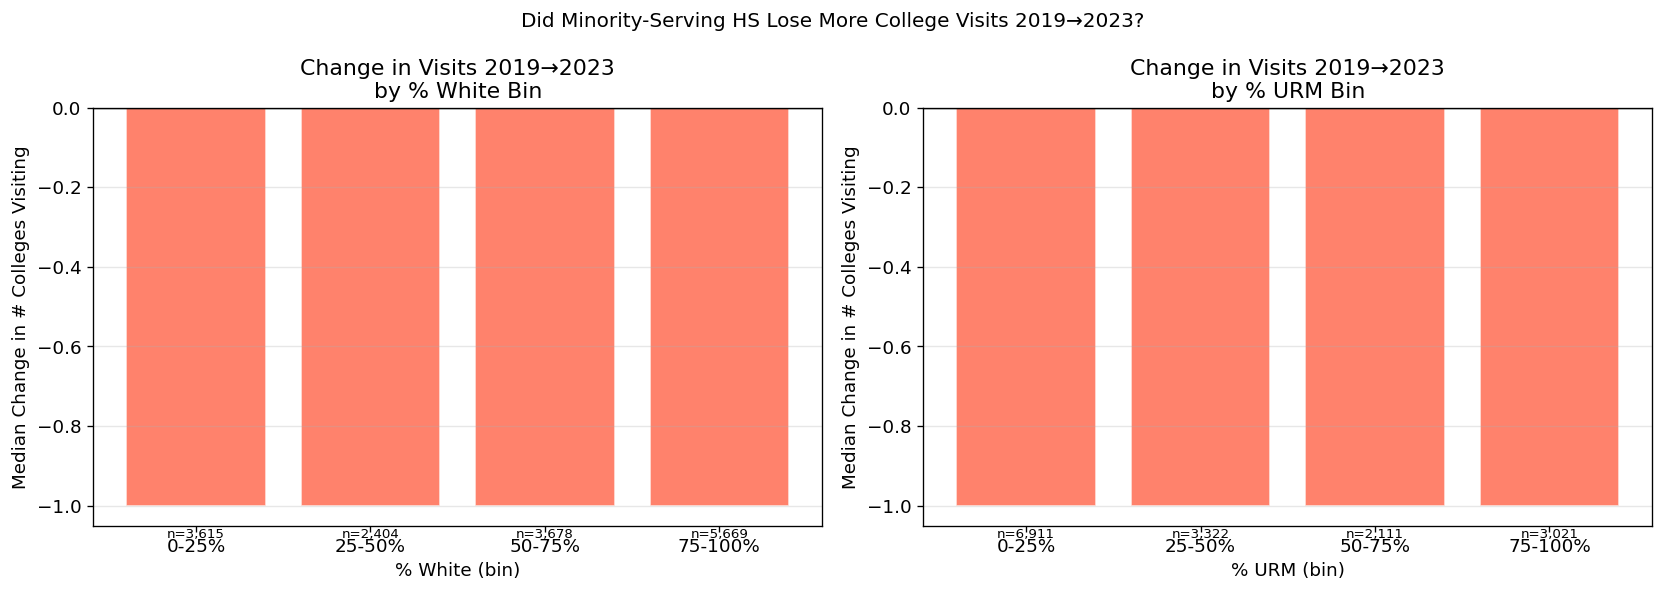


Median delta by % white bin:
           median  mean  count
white_bin                     
0-25%        -1.0 -2.14   3615
25-50%       -1.0 -2.30   2404
50-75%       -1.0 -2.35   3678
75-100%      -1.0 -1.41   5669

Median delta by % URM bin:
         median  mean  count
urm_bin                     
0-25%      -1.0 -1.70   6911
25-50%     -1.0 -2.29   3322
50-75%     -1.0 -2.03   2111
75-100%    -1.0 -2.06   3021


In [21]:
# Change in visits 2019→2023 by racial composition
# For HS present in both years, did predominantly minority schools lose more visits?

rdf19 = race_dfs[2019][['hs_id', 'in_degree', 'hs_pct_white', 'pct_urm',
                          'hs_pct_black', 'hs_pct_hispanic', 'school_type']].copy()
rdf23 = race_dfs[2023][['hs_id', 'in_degree']].copy()
rdf19.columns = ['hs_id', 'deg_2019', 'pct_white', 'pct_urm',
                  'pct_black', 'pct_hispanic', 'school_type']
rdf23.columns = ['hs_id', 'deg_2023']

both_hs = rdf19.merge(rdf23, on='hs_id').dropna(subset=['pct_white'])
both_hs['delta'] = both_hs['deg_2023'] - both_hs['deg_2019']

print(f'HS in both years with race data: {len(both_hs):,}')
print(f'Gained visits: {(both_hs["delta"] > 0).sum():,}  '
      f'Lost: {(both_hs["delta"] < 0).sum():,}  '
      f'Unchanged: {(both_hs["delta"] == 0).sum():,}')

# Bin by % white and look at median delta
both_hs['white_bin'] = pd.cut(both_hs['pct_white'],
                               bins=[0, 0.25, 0.50, 0.75, 1.0],
                               labels=['0-25%', '25-50%', '50-75%', '75-100%'],
                               include_lowest=True)
both_hs['urm_bin'] = pd.cut(both_hs['pct_urm'],
                              bins=[0, 0.25, 0.50, 0.75, 1.0],
                              labels=['0-25%', '25-50%', '50-75%', '75-100%'],
                              include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, xlabel in [
    (axes[0], 'white_bin', '% White'),
    (axes[1], 'urm_bin',   '% URM'),
]:
    groups = both_hs.groupby(col, observed=True)['delta'].agg(['median', 'mean', 'count'])
    colors = ['tomato' if m < 0 else 'steelblue' for m in groups['median']]
    ax.bar(groups.index.astype(str), groups['median'], color=colors, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'{xlabel} (bin)')
    ax.set_ylabel('Median Change in # Colleges Visiting')
    ax.set_title(f'Change in Visits 2019→2023\nby {xlabel} Bin')
    for j, (idx, row) in enumerate(groups.iterrows()):
        ax.text(j, row['median'] + (0.02 if row['median'] >= 0 else -0.08),
                f"n={int(row['count']):,}", ha='center', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Did Minority-Serving HS Lose More College Visits 2019→2023?', fontsize=12)
plt.tight_layout()
plt.savefig('../data/network_race_visit_change.png', bbox_inches='tight')
plt.show()

print('\nMedian delta by % white bin:')
print(both_hs.groupby('white_bin', observed=True)['delta'].agg(['median','mean','count']).round(2))
print('\nMedian delta by % URM bin:')
print(both_hs.groupby('urm_bin', observed=True)['delta'].agg(['median','mean','count']).round(2))

## Summary Table

In [22]:
summary = []
for yr, G in [('2019', G2019), ('2023', G2023)]:
    col_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'college']
    hs_nodes  = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'hs']
    od = [G.out_degree(n) for n in col_nodes]
    id_ = [G.in_degree(n) for n in hs_nodes]
    summary.append({
        'Year': yr,
        'Colleges': len(col_nodes),
        'High Schools': len(hs_nodes),
        'Edges': G.number_of_edges(),
        'Density': f"{G.number_of_edges() / (len(col_nodes) * len(hs_nodes)):.4%}",
        'Avg HS/College': f"{np.mean(od):.1f}",
        'Median HS/College': int(np.median(od)),
        'Max HS/College': max(od),
        'Avg Colleges/HS': f"{np.mean(id_):.1f}",
        'Median Colleges/HS': int(np.median(id_)),
        'Max Colleges/HS': max(id_),
    })

pd.DataFrame(summary).T

,0,1
Year,2019,2023
Colleges,2632,2536
High Schools,21692,18495
Edges,100540,60081
Density,0.1761%,0.1281%
Avg HS/College,38.2,23.7
Median HS/College,20,14
Max HS/College,644,258
Avg Colleges/HS,4.6,3.2
Median Colleges/HS,3,2
